# Data Preparation

Builds all processed parquet files used by the three city analysis notebooks.
Cook County uses five raw parquets; NYC uses MapPLUTO CSV + rolling sales; Philadelphia uses OPA assessments + PHLOTE sales.
All outputs are saved to `data/processed/`.

In [1]:
import sys, os
from pathlib import Path
_here = Path(os.path.abspath(''))
sys.path.insert(0, str(_here if (_here / 'src').exists() else _here.parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.city_data_utils import (
    fetch_acs_tracts,
    clean_nyc_pluto, clean_nyc_sales, build_nyc_datasets,
    clean_philly_assessments, clean_philly_sales, build_philly_datasets,
)
from src.data_utils import (
    load_raw_data, clean_assessed,
    clean_sales as clean_cook_sales,
    clean_chars, clean_parcels, clean_census,
    merge_parcels, merge_spatial,
    add_derived, create_subsets,
)
from src.config import RAW_DIR, PROCESSED_DIR, get_city_config

cook_cfg = get_city_config('cook')
nyc_cfg = get_city_config('nyc')
philly_cfg = get_city_config('philly')


def load_or_fetch_census(parquet_path, state_fips, county_fips_list, year=2023):
    """Load existing census parquet; fetch from Census Bureau API if not found."""
    p = Path(parquet_path)
    if p.exists():
        print(f'  Loading existing: {p.name}')
        return pd.read_parquet(p)
    print(f'  Fetching ACS {year} data for state {state_fips} ...')
    census = fetch_acs_tracts(state_fips, county_fips_list, year=year)
    census.to_parquet(p, index=False)
    print(f'  Saved to {p.name}')
    return census

## 1. Cook County, IL

Five separate raw parquets are merged into a single parcel-level dataset.
Residential properties are identified by class code 200–399.
Assessment level is **10%** of market value for residential and **25%** for commercial.
State equalizer (**3.0163×**, official 2023 Cook County equalization factor) and per-PIN composite rates from `pin_tax_codes.parquet` + `tax_rates_by_code_2023.parquet` (median ~7.5%; falls back to township estimates if rate files absent).
Spatial features (transit distances, density, environmental) are merged from `spatial_features.parquet` when available.

In [2]:
# -- load raw files
raw = load_raw_data()
assessed = clean_assessed(raw['assessed'])
cook_sales = clean_cook_sales(raw['sales'])
chars = clean_chars(raw['chars'])
parcels = clean_parcels(raw['parcels'])
census = clean_census(raw['census'])

# -- merge and derive
cook_all = merge_parcels(assessed, chars, parcels, census)
cook_all = merge_spatial(cook_all, RAW_DIR)
cook_all = add_derived(cook_all)
cook_res, cook_train = create_subsets(cook_all, cook_sales)

# -- save
cook_all.to_parquet(
    PROCESSED_DIR / cook_cfg['files']['all_parcels'], index=False)
cook_res.to_parquet(
    PROCESSED_DIR / cook_cfg['files']['residential'],  index=False)
cook_train.to_parquet(
    PROCESSED_DIR / cook_cfg['files']['training'],     index=False)

cook_match = cook_all['median_household_income'].notna().mean() * 100
print(f'Cook County saved:')
print(f'  All parcels:  {len(cook_all):,}')
print(f'  Residential:  {len(cook_res):,}')
print(f'  Training set: {len(cook_train):,}')
print(f'  Census match: {cook_match:.1f}%')

Loading raw data...
  assessed: (1864161, 19)
  sales: (287490, 20)
  chars: (1583785, 81)
  parcels: (1873421, 7)
  census: (1332, 19)
  Spatial features merged: 1,880,680/1,893,758 PINs matched
Cook County saved:
  All parcels:  1,893,758
  Residential:  1,635,253
  Training set: 127,549
  Census match: 79.6%


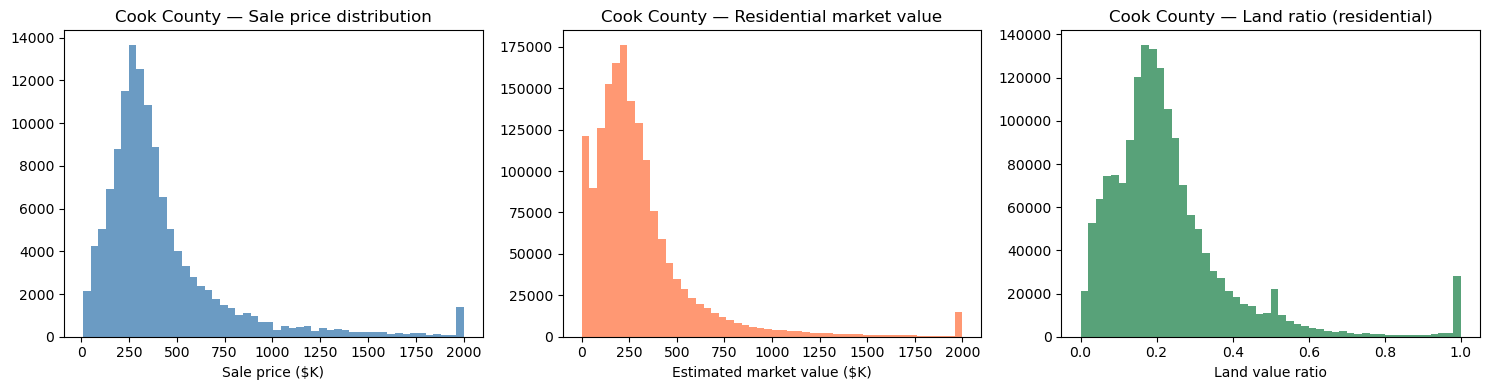

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cook_train['sale_price'].clip(upper=2_000_000) / 1e3,
             bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Sale price ($K)')
axes[0].set_title('Cook County — Sale price distribution')

axes[1].hist(cook_res['market_value_total'].clip(upper=2_000_000) / 1e3,
             bins=50, color='coral', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Estimated market value ($K)')
axes[1].set_title('Cook County — Residential market value')

axes[2].hist(cook_res['land_ratio'].dropna().clip(0, 1),
             bins=50, color='seagreen', alpha=0.8, edgecolor='none')
axes[2].set_xlabel('Land value ratio')
axes[2].set_title('Cook County — Land ratio (residential)')

plt.tight_layout()
plt.show()

## 2. New York City, NY

**Sources**: NYC MapPLUTO (all 5 boroughs) + annual rolling sales file.

Key differences from Cook County:
- **BBL** (Borough-Block-Lot) is the 10-digit parcel identifier
- **Assessed value IS the tax base** — no separate land/building assessment parcel files
- Class 1 (1–3 family) properties are statutorily assessed at **≈6% of market value**
- **Census GEOID**: PLUTO `tract2010` uses a hybrid scale — multiplied by 100 only when result < 1,000,000; achieves ~90% ACS match
- Sale price ceiling raised to **$50M** to capture high-value NYC transactions

In [4]:
# -- load raw CSV files
pluto = clean_nyc_pluto(str(RAW_DIR / 'nyc' / 'pluto.csv'))
nyc_sales = clean_nyc_sales(str(RAW_DIR / 'nyc' / 'sales.csv'))

# -- census (loads cached parquet or fetches from API)
# NYC counties: Manhattan(061), Bronx(005), Brooklyn(047), Queens(081), SI(085)
print('Census data:')
census_nyc = load_or_fetch_census(
    PROCESSED_DIR / 'nyc_census_acs_2023.parquet',
    state_fips='36',
    county_fips_list=['061', '005', '047', '081', '085'],
)
print(f'  {len(census_nyc):,} census tracts')

NYC PLUTO loaded: 858,644 parcels
  Census GEOID coverage: 858,644 (100.0%)
NYC Sales loaded: 260,927 arm's-length transactions
Census data:
  Loading existing: nyc_census_acs_2023.parquet
  2,327 census tracts


In [5]:
nyc_all, nyc_res, nyc_train = build_nyc_datasets(pluto, nyc_sales, census_nyc)

nyc_all.to_parquet(
    PROCESSED_DIR / nyc_cfg['files']['all_parcels'], index=False)
nyc_res.to_parquet(
    PROCESSED_DIR / nyc_cfg['files']['residential'],  index=False)
nyc_train.to_parquet(
    PROCESSED_DIR / nyc_cfg['files']['training'],     index=False)

print(f'NYC parquets saved to {PROCESSED_DIR.name}/')


NYC datasets built:
  all_parcels:  858,644
  residential:  705,173
    Class 1 (AVM scope):  565,301
    Class 2 (income cap): 139,872  — excluded from AVM per RPTL §581
  training_set: 114,754
  Census match: 89.0%
NYC parquets saved to processed/


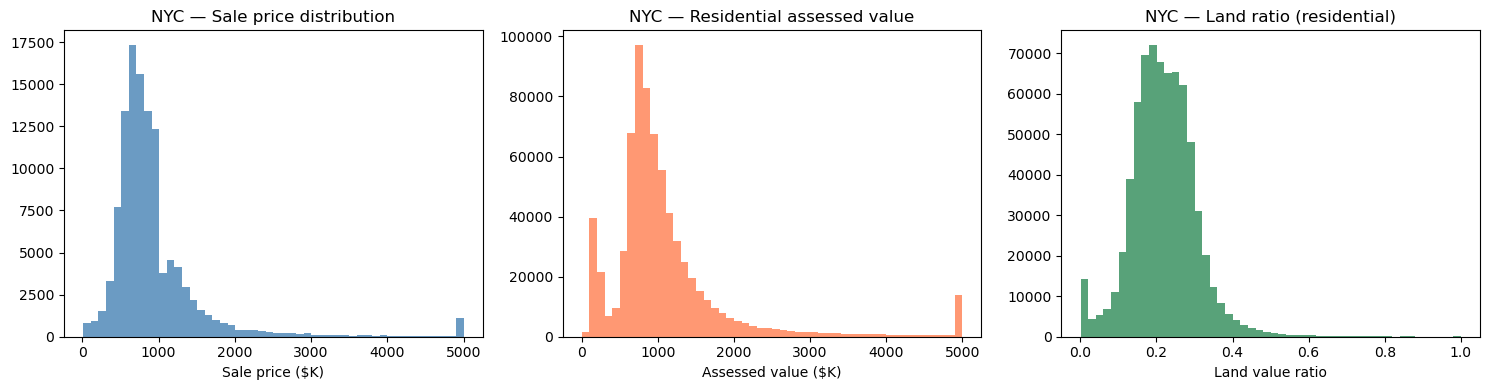

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(nyc_train['sale_price'].clip(upper=5_000_000) / 1e3,
             bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Sale price ($K)')
axes[0].set_title('NYC — Sale price distribution')

axes[1].hist(nyc_res['market_value_total'].clip(upper=5_000_000) / 1e3,
             bins=50, color='coral', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Assessed value ($K)')
axes[1].set_title('NYC — Residential assessed value')

axes[2].hist(nyc_res['land_ratio'].dropna().clip(0, 1),
             bins=50, color='seagreen', alpha=0.8, edgecolor='none')
axes[2].set_xlabel('Land value ratio')
axes[2].set_title('NYC — Land ratio (residential)')

plt.tight_layout()
plt.show()

## 3. Philadelphia, PA

**Sources**: OPA (Office of Property Assessment) assessments + PHLOTE sales.

Key differences from Cook County:
- **Full-value assessment**: Philly targets 100% of market value — `market_value` IS the tax base, no equalization factor
- **`taxable_land` / `taxable_building`** are the land/improvement splits used for the LVT simulation
- **No coordinates** in the OPA dataset — geographic cluster maps are skipped in the Philly notebook
- **Census GEOID**: OPA `census_tract` integer × 100, zero-padded to 6 digits; achieves ~65% ACS match
- Property type from `category_code`: 1 = Single Family, 2 = Multi Family → `is_residential`

In [7]:
# -- load raw CSV files
assess = clean_philly_assessments(str(RAW_DIR / 'philly' / 'assessments.csv'))
philly_sales = clean_philly_sales(str(RAW_DIR / 'philly' / 'sales.csv'))

# -- census (loads cached parquet or fetches from API)
# Pennsylvania FIPS = 42; Philadelphia County FIPS = 101
print('Census data:')
census_philly = load_or_fetch_census(
    PROCESSED_DIR / 'philly_census_acs_2023.parquet',
    state_fips='42',
    county_fips_list=['101'],
)
print(f'  {len(census_philly):,} census tracts')

Philadelphia assessments loaded: 583,558 parcels
  Census GEOID coverage: 583,558 (100.0%)
Philadelphia sales loaded: 150,204 arm's-length transactions (2019+)
Census data:
  Loading existing: philly_census_acs_2023.parquet
  408 census tracts


In [8]:
ph_all, ph_res, ph_train = build_philly_datasets(
    assess, philly_sales, census_philly)

ph_all.to_parquet(
    PROCESSED_DIR / philly_cfg['files']['all_parcels'], index=False)
ph_res.to_parquet(
    PROCESSED_DIR / philly_cfg['files']['residential'],  index=False)
ph_train.to_parquet(
    PROCESSED_DIR / philly_cfg['files']['training'],     index=False)

print(f'Philadelphia parquets saved to {PROCESSED_DIR.name}/')

  Abated parcels imputed: 42,470  median land share: 0.200

Philadelphia datasets built:
  all_parcels:  583,558
  residential:  504,034
  training_set: 135,712
  Census match: 64.0%
Philadelphia parquets saved to processed/


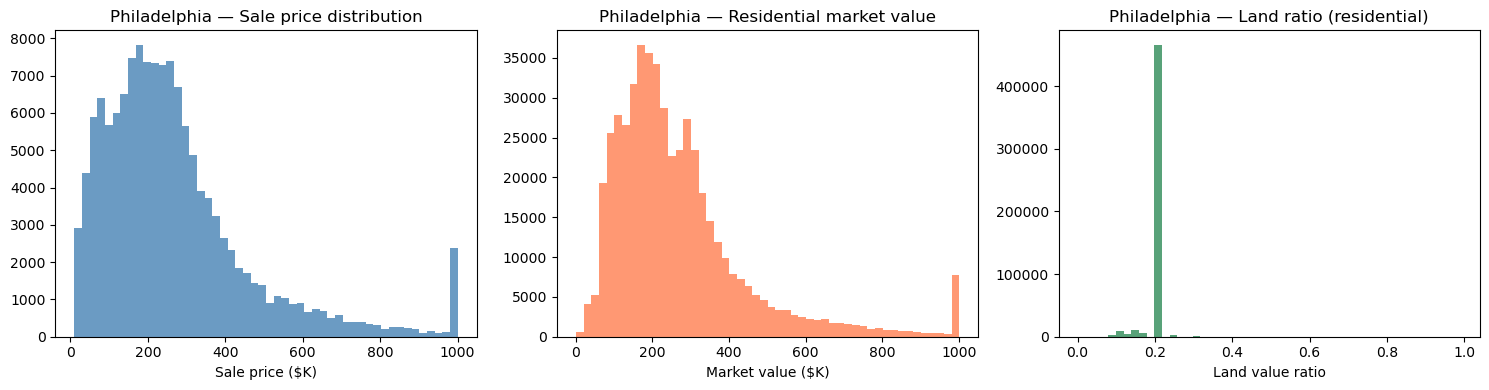

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ph_train['sale_price'].clip(upper=1_000_000) / 1e3,
             bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Sale price ($K)')
axes[0].set_title('Philadelphia — Sale price distribution')

axes[1].hist(ph_res['market_value_total'].clip(upper=1_000_000) / 1e3,
             bins=50, color='coral', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Market value ($K)')
axes[1].set_title('Philadelphia — Residential market value')

axes[2].hist(ph_res['land_ratio'].dropna().clip(0, 1),
             bins=50, color='seagreen', alpha=0.8, edgecolor='none')
axes[2].set_xlabel('Land value ratio')
axes[2].set_title('Philadelphia — Land ratio (residential)')

plt.tight_layout()
plt.show()

## 4. Cross-City Summary

,All parcels,Residential,Training set,Census match,Median sale
City,,,,,
"Cook County, IL","1,893,758","1,635,253","127,549",79.6%,$325K
"New York City, NY","858,644","705,173","114,754",89.0%,$785K
"Philadelphia, PA","583,558","504,034","135,712",64.0%,$228K


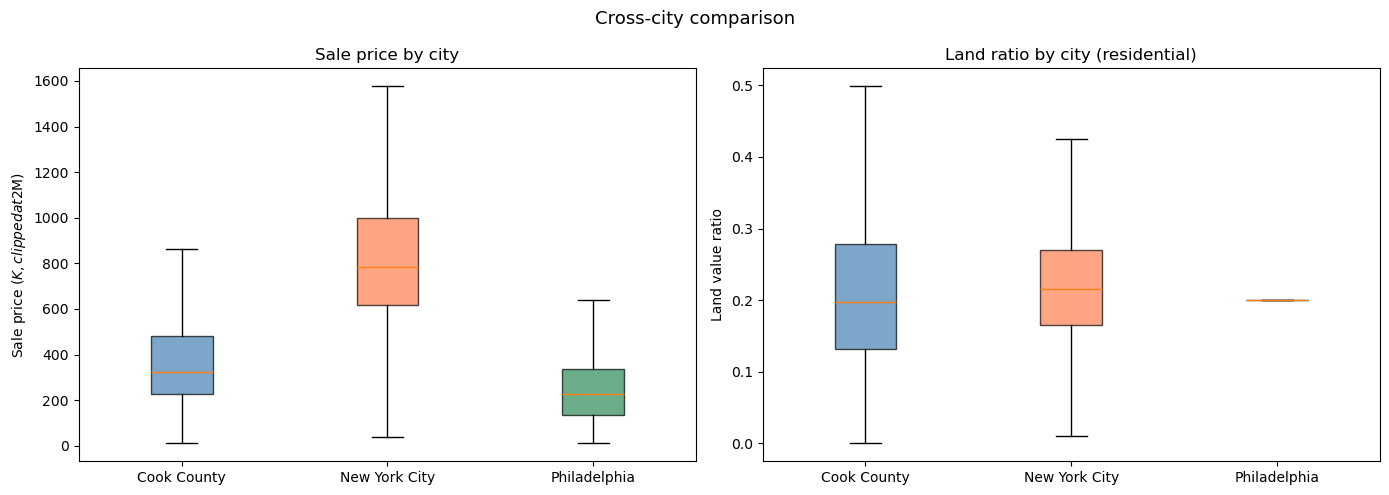

In [10]:
# -- summary table
cook_match = cook_all['median_household_income'].notna().mean() * 100
nyc_match = nyc_all['median_household_income'].notna().mean() * 100
philly_match = ph_all['median_household_income'].notna().mean() * 100

cook_med = cook_train['sale_price'].median() / 1e3
nyc_med = nyc_train['sale_price'].median() / 1e3
philly_med = ph_train['sale_price'].median() / 1e3

summary = pd.DataFrame({
    'City':         ['Cook County, IL', 'New York City, NY', 'Philadelphia, PA'],
    'All parcels':  [f'{len(cook_all):,}',   f'{len(nyc_all):,}',   f'{len(ph_all):,}'],
    'Residential':  [f'{len(cook_res):,}',   f'{len(nyc_res):,}',   f'{len(ph_res):,}'],
    'Training set': [f'{len(cook_train):,}', f'{len(nyc_train):,}', f'{len(ph_train):,}'],
    'Census match': [f'{cook_match:.1f}%',   f'{nyc_match:.1f}%',   f'{philly_match:.1f}%'],
    'Median sale':  [f'${cook_med:.0f}K',    f'${nyc_med:.0f}K',    f'${philly_med:.0f}K'],
})
display(summary.set_index('City'))

# -- comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_labels = ['Cook County', 'New York City', 'Philadelphia']
colors = ['steelblue', 'coral', 'seagreen']

sale_data = [
    cook_train['sale_price'].clip(0, 2e6).values / 1e3,
    nyc_train['sale_price'].clip(0, 2e6).values / 1e3,
    ph_train['sale_price'].clip(0, 2e6).values / 1e3,
]
bp = axes[0].boxplot(sale_data, tick_labels=city_labels,
                     showfliers=False, patch_artist=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Sale price ($K, clipped at $2M)')
axes[0].set_title('Sale price by city')

land_data = [
    cook_res['land_ratio'].dropna().clip(0, 1).values,
    nyc_res['land_ratio'].dropna().clip(0, 1).values,
    ph_res['land_ratio'].dropna().clip(0, 1).values,
]
bp2 = axes[1].boxplot(land_data, tick_labels=city_labels,
                      showfliers=False, patch_artist=True)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Land value ratio')
axes[1].set_title('Land ratio by city (residential)')

plt.suptitle('Cross-city comparison', fontsize=13)
plt.tight_layout()
plt.show()